# Environment Setup

In [ ]:
!pip install transformers==4.37.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.9 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.20.3
    Uninstalling tokenizers-0.20.3:
      Successfully uninstalled tokenizers-0.20.3
  Attempting uninstall: transformers
    Found existing installation: transformers 4.46.2
    Uninstalling transformers-4.46.2:
      Successfully uninstalled transformers-4.46.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 3.2.1 requires transformers<5.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.


In [2]:
!pip install decord -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 106.3 MB/s eta 0:00:00


# Library Import

In [1]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

shared_folder_path = '/content/drive/MyDrive/ECE1786/ECE1786_project'
os.listdir(shared_folder_path)


Mounted at /content/drive


['internvl-2B',
 'data',
 'InternVL-main',
 'product_data.jsonl',
 'meta_file.json',
 'diningtables150-200.csv',
 'Data.xlsx',
 'data1-50.csv',
 'internvl-8B',
 'test',
 'officetable51-100.xlsx',
 'product_data_full.csv',
 'internvl-4B',
 'internvl2_eval.ipynb',
 'product_data_full.jsonl',
 'product_database.csv',
 'match.ipynb',
 'data_integration.ipynb',
 'user_data.jsonl',
 'meta_file_full.json',
 'internvl_sft.ipynb',
 'user_query.csv',
 'data_processing.ipynb',
 'internvl2_test.ipynb']

In [3]:
import numpy as np
import torch
import torchvision.transforms as T
from decord import VideoReader, cpu
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import re

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Load Data

In [4]:
test_csv_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/test/test.csv"
test_df = pd.read_csv(test_csv_path)
test_df.head()

,img_dir,price,label,description
0,1,88.97,"color: black / L: 40 - W: 19 - H: 28, inch / P...","SHW Desk Home Office 40-Inch Computer Table, B..."
1,2,169.87,"color: cherry/ L: 55 - W: 23.8 - H: 28, inch /...",SHW Commercial-Grade Computer Desk Home Office...
2,3,169.87,"color: maple/ L: 55 - W: 23.8 - H: 28, inch / ...",SHW Commercial-Grade Computer Desk Home Office...
3,4,99.87,"color: white/ L: 43 - W: 20 - H: 30, inch / Pr...",SHW Ivy Trestle Home Office Computer Desk with...
4,5,99.87,"color: espresso/ L: 43- W: 20 - H: 30, inch / ...",SHW Ivy Trestle Home Office Computer Desk with...


In [9]:
def label_anlysis(label):
  color_pattern = r'color:\s*([a-zA-Z\s]+)'
  size_pattern = r'L:\s*([\d.]+)\s*-\s*W:\s*([\d.]+)\s*-\s*H:\s*([\d.]+)'
  price_pattern = r'Price:\s*\$?([\d,]+\.\d+)'

  color_match = re.search(color_pattern, label)
  color = color_match.group(1).strip() if color_match else None

  # Extract dimensions (L, W, H)
  size_match = re.search(size_pattern, label)
  if size_match:
      length, width, height = size_match.groups()
  else:
      length, width, height = None, None, None

  # Extract price
  price_match = re.search(price_pattern, label)
  price = float(price_match.group(1).replace(',', '')) if price_match else None
  return color, length, width, height, price


In [38]:
# product database
product_csv_path = "/content/drive/MyDrive/ECE1786/ECE1786_project/product_data_full.csv"
product_df = pd.read_csv(product_csv_path)
product_database = pd.DataFrame(columns = ['img_dir', 'price', 'color', 'length', 'width', 'height'])

for i in range(len(product_df)):
  img_dir = product_df['img_dir'][i]
  label = product_df['label'][i]
  color, length, width, height, price = label_anlysis(label)
  product_database.loc[i] = [img_dir, price, color, length, width, height]

product_database

<ipython-input-38-3dcdcaab7e97>:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  product_database.loc[i] = [img_dir, price, color, length, width, height]
<ipython-input-38-3dcdcaab7e97>:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  product_database.loc[i] = [img_dir, price, color, length, width, height]
<ipython-input-38-3dcdcaab7e97>:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty 

,img_dir,price,color,length,width,height
0,1,129.99,white,39.4,18.9,30.5
1,2,169.99,white,55.1,18.9,30.5
2,3,149.99,white,47.2,18.9,30.5
3,4,199.99,white,63.0,18.5,30.7
4,5,299.87,maple,55.0,28.0,28.0
...,...,...,...,...,...,...
195,196,539.49,wood,55.1,27.6,29.5
196,197,206.49,beige,47,27.5,29.5
197,198,156.49,white,62.9,35.4,28.3
198,199,201.99,grey,31.5,31.5,29.9


In [39]:
product_database.to_csv('/content/drive/MyDrive/ECE1786/ECE1786_project/product_database.csv')

# Functions

In [5]:
def build_transform(input_size):
    MEAN, STD = IMAGENET_MEAN, IMAGENET_STD
    transform = T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=MEAN, std=STD)
    ])
    return transform

def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio = (1, 1)
    area = width * height
    for ratio in target_ratios:
        target_aspect_ratio = ratio[0] / ratio[1]
        ratio_diff = abs(aspect_ratio - target_aspect_ratio)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio

def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio = orig_width / orig_height

    # calculate the existing image aspect ratio
    target_ratios = set(
        (i, j) for n in range(min_num, max_num + 1) for i in range(1, n + 1) for j in range(1, n + 1) if
        i * j <= max_num and i * j >= min_num)
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])

    # find the closest aspect ratio to the target
    target_aspect_ratio = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)

    # calculate the target width and height
    target_width = image_size * target_aspect_ratio[0]
    target_height = image_size * target_aspect_ratio[1]
    blocks = target_aspect_ratio[0] * target_aspect_ratio[1]

    # resize the image
    resized_img = image.resize((target_width, target_height))
    processed_images = []
    for i in range(blocks):
        box = (
            (i % (target_width // image_size)) * image_size,
            (i // (target_width // image_size)) * image_size,
            ((i % (target_width // image_size)) + 1) * image_size,
            ((i // (target_width // image_size)) + 1) * image_size
        )
        # split the image
        split_img = resized_img.crop(box)
        processed_images.append(split_img)
    assert len(processed_images) == blocks
    if use_thumbnail and len(processed_images) != 1:
        thumbnail_img = image.resize((image_size, image_size))
        processed_images.append(thumbnail_img)
    return processed_images

def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB')
    transform = build_transform(input_size=input_size)
    images = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = [transform(image) for image in images]
    pixel_values = torch.stack(pixel_values)
    return pixel_values

In [6]:
def response_anaylsis(response):
  color_pattern = r'color:\s*([\w\s]+)'
  size_pattern = r'L:\s*([\d.]+)[\s,-]*W:\s*([\d.]+)[\s,-]*H:\s*([\d.]+)'
  price_pattern = r'Price:\s*\$?([\d,]+\.\d+)'

  color_match = re.search(color_pattern, response, re.IGNORECASE)
  color = color_match.group(1).strip() if color_match else None

  # Extract size (L, W, H)
  size_match = re.search(size_pattern, response)
  if size_match:
      length, width, height = size_match.groups()
  else:
      length, width, height = None, None, None

  # Extract price with optional "$" sign
  price_match = re.search(price_pattern, response)
  price = float(price_match.group(1).replace(',', '')) if price_match else None


  return color, length, width, height, price

In [86]:
for i in range(len(response_recording)):
  print(response_recording[i])
  color, length, width, height, price = response_anaylsis(response_recording[i])
  print(color, length, width, height, price)

Color: black / L: 40 - W: 28 - H: 19-inch / Price: 88.97
black 40 28 19 88.97
Color: red / L: 55 - W: 23.8 - H: 28, inch / Price: 169.87
red 55 23.8 28 169.87
Color: beige / L: 55 - W: 23.8 - H: 28, inch / Price: $69.87
beige 55 23.8 28 69.87
Color: white / L: 43 inch / W: 7.5 inch / H: 16 inch, Price: 99.87
white None None None 99.87
Color: espresso / L: 43, - W: 20, - H: 30,-inch / Price: 99.87
espresso 43 20 30 99.87
Color: black / L: 84 cm - W: 84 cm - H: 90 cm / Price: 119.99
black None None None 119.99
Color: lime green / L: 47.2 - W: 27.6 - H: 29.5, inch / Price: 119.99
lime green 47.2 27.6 29.5 119.99
Color: espresso / L: 47.2 - W: 29.5 - H: 37.8 / Price: 0.00
espresso 47.2 29.5 37.8 0.0
Color: wood / L: 47.2 - W: 27.2 - H: 29.5, inch / Price: $119.99
wood 47.2 27.2 29.5 119.99
Color: Lime / L: 47.2 - W: 27.2 - H: 25.8, inch / Price: 119.99
Lime 47.2 27.2 25.8 119.99


In [76]:
# for i in range(len(test_df)):
#   label = test_df['label'][i]
#   color, length, width, height, price = label_anlysis(label)
#   print(color, length, width, height, price)

black 40 19 28 88.97
cherry 55 23.8 28 169.87
maple 55 23.8 28 169.87
white 43 20 30 99.87
espresso 43 20 30 99.87
black 47.2 27.5 29.5 119.99
white 47.2 27.6 29.5 119.99
espresso 47.2 29.5 29 459.99
oak 47.2 27.2 29.5 119.99
grey 47.2 27.2 29.5 119.99


# Model Evaluate

## 2B Model

In [7]:
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl2_2b_internlm2_1_8b_dynamic_res_2nd_finetune_full'
model_2b = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


configuration_internvl_chat.py:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

configuration_internlm2.py:   0%|          | 0.00/7.00k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-2B:
- configuration_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


configuration_intern_vit.py:   0%|          | 0.00/5.55k [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-2B:
- modeling_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


conversation.py:   0%|          | 0.00/15.0k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-2B:
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-2B:
- modeling_internvl_chat.py
- modeling_intern_vit.py
- modeling_internlm2.py
- conversation.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention2 is not installed.


InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


In [ ]:
# single-image single-round conversation (单图单轮对话)
# img_path = '/content/gdrive/MyDrive/ECE1786_project/data/192/192.jpg'
# product_title = 'Dining Table 31.5x31.5x29.92 inch High Gloss White'
# price = '468.7'
# prompt_sg = f"Product image1:<image>\nProduct title:{product_title} price is {price}\nExtract features based on the image and title.\nFeatures:"
# pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
# question = prompt_sg
# response = model.chat(tokenizer, pixel_values, question, generation_config)
# print(f'User: {question}"{response}"')
response_recording = []
color_correct = 0
price_correct = 0
product_information = {}
predict_information = {}
for i in range(len(test_df)):
  img_path = f"/content/drive/MyDrive/ECE1786/ECE1786_project/test/{test_df['img_dir'][i]}/{test_df['img_dir'][i]}.jpg"
  if not os.path.exists(img_path):
    print(f"product {test_df['img_dir'][i]} image not exist")

  product_title = test_df['description'][i]
  price = test_df['price'][i]
  prompt_sg = f"Product image1:<image>\nProduct title:{product_title} price is {price}.\nExtract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'.\nFeatures:"
  pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
  question = prompt_sg
  response = model_2b.chat(tokenizer, pixel_values, question, generation_config)
  print(f'User: {question}"{response}"')
  response_recording.append(response)

  # get lable information
  label = test_df['label'][i]
  color, length, width, height, price = label_anlysis(label)
  product_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}

  # get predict information
  color, length, width, height, price = response_anaylsis(response)
  predict_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}



User: Product image1:<image>
Product title:SHW Desk Home Office 40-Inch Computer Table, Black price is 88.97.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'.
Features:"Color: black / L: 40 SIZE: 19 INCH / W: 19 INCH SIZE: 28 INCH / Price: 88.97"
User: Product image1:<image>
Product title:SHW Commercial-Grade Computer Desk Home Office Table, Black Frame w/Cherry Top, 55-Inch price is 169.87.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'.
Features:"Color: cherry / L: 55 inch - W: 23.8 inch - H: 28 inch / Price: 169.87"
User: Product image1:<image>
Product title:SHW Commercial-Grade Computer Desk Home Office Table, Maple, 55-Inch price is 169.87.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH

In [ ]:
def size_compare(prod1, prod2):
  if prod1['length'] == prod2['length']:
    if prod1['width'] == prod2['width']:
      if prod1['height'] == prod2['height']:
        return True
  return False

color_correct = 0
price_correct = 0
size_correct = 0
error_list = []
correct = 0
for i in range(len(predict_information)):
  # color match
  flag = True
  if predict_information[i]['color'] and product_information[i]['color']:
    if predict_information[i]['color'].lower() == product_information[i]['color'].lower():
      color_correct += 1


  # size match
  if size_compare(predict_information[i], product_information[i]):
    size_correct += 1
  else:
    flag = False

  #price match
  if predict_information[i]['price'] == product_information[i]['price']:
    price_correct += 1

  if flag == False:
    error_list.append(i)
  else:
    correct += 1



print("Color Classification Accuracy: ", color_correct/len(predict_information))
print("Price Classification Accuracy: ", price_correct/len(predict_information))
print("Size Classification Accuracy: ", size_correct/len(predict_information))
print("Accuracy: ", correct/len(predict_information))
print(error_list)

In [116]:
for i in error_list:
  print(f"\n{i}th Information")
  print("Response Recording: ", response_recording[i])
  print("Truth Label: ", test_df['label'][i])



1th Information
Response Recording:  Color: red / L: 55 - W: 23.8 - H: 28, inch / Price: 169.87
Truth Label:  color: cherry/ L: 55 - W: 23.8 - H: 28, inch / Price: 169.87

2th Information
Response Recording:  Color: #B2 / L: 55 - W: 28 - H: 28, inch / Price: 169.87
Truth Label:  color: maple/ L: 55 - W: 23.8 - H: 28, inch / Price: 169.87

3th Information
Response Recording:  Color: white / L: 43.0 / W: 30.0 / H: 19.0 / inch / Price: 99.87
Truth Label:  color: white/ L: 43 - W: 20 - H: 30, inch / Price: 99.87

4th Information
Response Recording:  Color: espresso / L: 43.0, W: 20.0, H: 30.0, inch / Price: 99.87
Truth Label:  color: espresso/ L: 43- W: 20 - H: 30, inch / Price: 99.87

5th Information
Response Recording:  Color: black / L: 95, W: 95, H: 95 / Price: 119.99
Truth Label:  color: black/ L: 47.2 - W: 27.5 - H: 29.5, inch / Price: 119.99

6th Information
Response Recording:  Color:  white / L: 47.2 - W: 29.5 - H: 29.5 inch, inch / Price: 119.99
Truth Label:  color: white/ L: 47

In [109]:
Color Classification Accuracy:  0.5
Price Classification Accuracy:  0.9
Size Classification Accuracy:  0.4
Accuracy:  0.3
[2, 3, 4, 5, 7, 8, 9]

Color Classification Accuracy:  0.6
Price Classification Accuracy:  0.9
Size Classification Accuracy:  0.2
Accuracy:  0.1
[0, 1, 2, 3, 5, 6, 7, 8, 9]

SyntaxError: invalid syntax (<ipython-input-109-1380f8354965>, line 1)

## 4B Model


In [5]:
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl_4b_lora_merged'
model_4b = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


configuration_internvl_chat.py:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

configuration_phi3.py:   0%|          | 0.00/10.4k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-4B:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


configuration_intern_vit.py:   0%|          | 0.00/5.55k [00:00<?, ?B/s]

...

modeling_intern_vit.py:   0%|          | 0.00/18.1k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-4B:
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-4B:
- modeling_internvl_chat.py
- conversation.py
- modeling_phi3.py
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.10/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention2 is not installed.


Phi3ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [54]:
response_recording = []
color_correct = 0
price_correct = 0
product_information = {}
predict_information = {}
for i in range(len(test_df)):
  img_path = f"/content/drive/MyDrive/ECE1786/ECE1786_project/test/{test_df['img_dir'][i]}/{test_df['img_dir'][i]}.jpg"
  if not os.path.exists(img_path):
    print(f"product {test_df['img_dir'][i]} image not exist")

  product_title = test_df['description'][i]
  price = test_df['price'][i]
  prompt_sg = f"Product image1:<image>\nProduct title:{product_title} price is {price}.\nExtract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'."
  pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
  question = prompt_sg
  response = model_4b.chat(tokenizer, pixel_values, question, generation_config)
  print(f'User: {question}"{response}"')
  response_recording.append(response)

  # get lable information
  label = test_df['label'][i]
  color, length, width, height, price = label_anlysis(label)
  product_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}

  # get predict information
  color, length, width, height, price = response_anaylsis(response)
  predict_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}


User: Product image1:<image>
Product title:SHW Desk Home Office 40-Inch Computer Table, Black price is 88.97.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'."Color: black / L: 40 - W: 28 - H: 19, inch / Price: 88.97"
User: Product image1:<image>
Product title:SHW Commercial-Grade Computer Desk Home Office Table, Black Frame w/Cherry Top, 55-Inch price is 169.87.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'."Color: Cherry / L: 55 - W: 23.8 - H: 28, inch / Price: 169.87"
User: Product image1:<image>
Product title:SHW Commercial-Grade Computer Desk Home Office Table, Maple, 55-Inch price is 169.87.
Extract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'.

In [61]:
def size_compare(prod1, prod2):
  if float(prod1['length']) == float(prod2['length']):
    if float(prod1['width']) == float(prod2['width']):
      if float(prod1['height']) == float(prod2['height']):
        return True
  return False

color_correct = 0
price_correct = 0
size_correct = 0
error_list = []
correct = 0
for i in range(len(predict_information)):
  # color match
  flag = True
  if predict_information[i]['color'] and product_information[i]['color']:
    if predict_information[i]['color'].lower() == product_information[i]['color'].lower():
      color_correct += 1

  # size match
  if size_compare(predict_information[i], product_information[i]):
    size_correct += 1
  else:
    flag = False

  #price match
  if predict_information[i]['price'] == product_information[i]['price']:
    price_correct += 1


  if flag == False:
    error_list.append(i)
  else:
    correct += 1



print("Color Classification Accuracy: ", color_correct/len(predict_information))
print("Price Classification Accuracy: ", price_correct/len(predict_information))
print("Size Classification Accuracy: ", size_correct/len(predict_information))
print("Accuracy: ", correct/len(predict_information))
print(error_list)

Color Classification Accuracy:  0.0
Price Classification Accuracy:  0.9
Size Classification Accuracy:  0.7
Accuracy:  0.7
[0, 7, 8]


In [62]:
for i in error_list:
  print(f"\n{i}th Information")
  print("Response Recording: ", response_recording[i])
  print("Truth Label: ", test_df['label'][i])



0th Information
Response Recording:  Color: black / L: 40 - W: 28 - H: 19, inch / Price: 88.97
Truth Label:  color: black / L: 40 - W: 19 - H: 28, inch / Price: 88.97

7th Information
Response Recording:  Color: espresso / L: 47.2 - W: 29.5 - H: 37.8,inch / Price: 459.99
Truth Label:  color: espresso/ L: 47.2- W: 29.5 - H: 29, inch / Price: 459.99

8th Information
Response Recording:  Color: oak / L: 48.2 - W: 27.2 - H: 29.5, inch / Price: 119.99
Truth Label:  color: oak/ L: 47.2- W: 27.2 - H: 29.5, inch / Price: 119.99


Color Classification Accuracy:  0.7
Price Classification Accuracy:  1.0
Size Classification Accuracy:  0.3
Accuracy:  0.3


## 8B Model

In [25]:
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl_8b_lora_merged_new'
model_8b = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [64]:
response_recording = []
color_correct = 0
price_correct = 0
product_information = {}
predict_information = {}
for i in range(len(test_df)):
  img_path = f"/content/drive/MyDrive/ECE1786/ECE1786_project/test/{test_df['img_dir'][i]}/{test_df['img_dir'][i]}.jpg"
  if not os.path.exists(img_path):
    print(f"product {test_df['img_dir'][i]} image not exist")

  product_title = test_df['description'][i]
  price = test_df['price'][i]
  prompt_sg = f"Product image1:<image>\nProduct title:{product_title} price is {price}.\nExtract features based on the image and title and output with format: 'Color:[COLOR] / L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / Price: [PRICE]'."
  pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
  question = prompt_sg
  response = model_8b.chat(tokenizer, pixel_values, question, generation_config)
  print(f'User: {question}"{response}"')
  response_recording.append(response)

  # get lable information
  label = test_df['label'][i]
  color, length, width, height, price = label_anlysis(label)
  product_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}

  # get predict information
  color, length, width, height, price = response_anaylsis(response)
  predict_information[i] ={'color':color, 'length':length, 'width':width, 'height':height, 'price':price}


IndexError: piece id is out of range.

In [46]:
def size_compare(prod1, prod2):
  if prod1['length'] == prod2['length']:
    if prod1['width'] == prod2['width']:
      if prod1['height'] == prod2['height']:
        return True
  return False

color_correct = 0
price_correct = 0
size_correct = 0
error_list = []
correct = 0
for i in range(len(predict_information)):
  # color match
  flag = True
  if predict_information[i]['color'] and product_information[i]['color']:
    if predict_information[i]['color'].lower() == product_information[i]['color'].lower():
      color_correct += 1

  # size match
  if size_compare(predict_information[i], product_information[i]):
    size_correct += 1
  else:
    flag = False

  #price match
  if predict_information[i]['price'] == product_information[i]['price']:
    price_correct += 1


  if flag == False:
    error_list.append(i)
  else:
    correct += 1



print("Color Classification Accuracy: ", color_correct/len(predict_information))
print("Price Classification Accuracy: ", price_correct/len(predict_information))
print("Size Classification Accuracy: ", size_correct/len(predict_information))
print("Accuracy: ", correct/len(predict_information))
print(error_list)

Color Classification Accuracy:  0.0
Price Classification Accuracy:  1.0
Size Classification Accuracy:  0.8
Accuracy:  0.8
[1, 7]


In [47]:
for i in error_list:
  print(f"\n{i}th Information")
  print("Response Recording: ", response_recording[i])
  print("Truth Label: ", test_df['label'][i])



1th Information
Response Recording:  Color: cherry / L: 55.0 - W: 23.8 - H: 28.0, inch / Price: 169.87
Truth Label:  color: cherry/ L: 55 - W: 23.8 - H: 28, inch / Price: 169.87

7th Information
Response Recording:  Color: espresso / L: 47.2 - W: 29.5 - H: 28.3, inch / Price: 459.99
Truth Label:  color: espresso/ L: 47.2- W: 29.5 - H: 29, inch / Price: 459.99


# user query testing


In [56]:
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl_8b_lora_merged_new'
model_8b = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)

configuration_internvl_chat.py:   0%|          | 0.00/3.85k [00:00<?, ?B/s]

configuration_internlm2.py:   0%|          | 0.00/7.00k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-8B:
- configuration_internlm2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


configuration_intern_vit.py:   0%|          | 0.00/5.55k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-8B:
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-8B:
- configuration_internvl_chat.py
- configuration_internlm2.py
- configuration_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

modeling_intern_vit.py:   0%|          | 0.00/18.1k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-8B:
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/OpenGVLab/InternVL2-8B:
- modeling_internvl_chat.py
- conversation.py
- modeling_internlm2.py
- modeling_intern_vit.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


FlashAttention2 is not installed.


InternLM2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

# Product Match Pipeline

In [ ]:
path = '/content/drive/MyDrive/ECE1786/ECE1786_project/InternVL-main/internvl_chat/work_dirs/internvl_chat_v2_0/internvl_8b_lora_merged_new'
model_8b = AutoModel.from_pretrained(
    path,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    use_flash_attn=True,
    trust_remote_code=True).eval().cuda()
tokenizer = AutoTokenizer.from_pretrained(path, trust_remote_code=True, use_fast=False)
generation_config = dict(max_new_tokens=128, do_sample=True)

## User Query Feature Extract

In [76]:
# pure-text conversation
def user_query_feature_extract(query, model, tokenizer):
  question = f'User query: {query}\n Extract the search key from user query, like color, size, price. For the size I want the unit in inch. \n Output Format: color:[COLOR]/ L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / price: [PRICE] '
  response, history = model.chat(tokenizer, None, question, generation_config, history=None, return_history=True)
  print(f'User: {question}\n Assistant: {response}')
  return response

#query = "I need a dining table for a compact dining area. It should seat four people, be white, have a length of 59 inch, a depth of 30 inch, a height of 29 inch, and cost under 300."
# test_q = "Can I find an oak table that's 29.92 inches tall, 59.06 inches long, and 33.46 inches deep, for $350?"
# response = user_query_feature_extract(test_q, model_8b, tokenizer)

test_list = ["I'm looking for a white table with dimensions approximately 29.53 inches in height, 59.06 inches in length, and 35.43 inches in depth, priced around $300.",
"Do you have a brown table that's 29.53 inches tall, 78.74 inches long, and 35.43 inches deep, priced at $600?",
"I need a black table with dimensions of 30.71 inches in height, 78.74 inches in length, and 39.37 inches in depth, priced at $700.",
"Can you recommend an oak table that's 29.92 inches tall, 70.87 inches long, and 31.5 inches deep, priced at $800?",
"I'm searching for a white table with dimensions of 29.53 inches in height, 39.37 inches in length, and 39.37 inches in depth, costing $250.",
"Is there a dark brown table available that's 30.71 inches in height, 98.43 inches in length, and 39.37 inches in depth, priced at $1000?",
"Do you have a light gray table that measures 29.13 inches in height, 47.24 inches in length, and 27.56 inches in depth, for around $200?",
"I'm looking for a teak table with dimensions of 29.92 inches in height, 78.74 inches in length, and 39.37 inches in depth, priced at $500.",
"Can I get a white table that is 29.53 inches tall, 55.12 inches long, and 31.5 inches deep, costing $300?",
"I need a black table that's 29.13 inches in height, 47.24 inches in length, and 23.62 inches in depth, for $400.",
"Do you have an oak table that is 29.13 inches tall, 59.06 inches long, and 23.62 inches deep, priced at $400?",
"I'm searching for a white table with dimensions of 45.05 inches in height, 62.99 inches in length, and 27.56 inches in depth, priced at $600.",
"Can I find a black table that's 29.53 inches in height, 39.37 inches in length, and 19.69 inches in depth, priced at $250?",
"Do you have a black table with dimensions of 30.71 inches in height, 70.87 inches in length, and 31.5 inches in depth, for $800?",
"I need a white table that's 29.92 inches tall, 59.06 inches long, and 23.62 inches deep, priced at $500.",
"Is there a brown table that's 29.53 inches in height, 70.87 inches in length, and 27.56 inches in depth, priced at $700?",
]

outputs = []
for q in test_list:
  response = user_query_feature_extract(q, model_8b, tokenizer)
  info = userq_response_anlysis(response)
  outputs.append(info)

User: User query: I'm looking for a white table with dimensions approximately 29.53 inches in height, 59.06 inches in length, and 35.43 inches in depth, priced around $300.
 Extract the search key from user query, like color, size, price. For the size I want the unit in inch. 
 Output Format: color:[COLOR]/ L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / price: [PRICE] 
 Assistant: color: white / L: 59.06 - W: 35.43 - H: 29.53, inch / price: 300
User: User query: Do you have a brown table that's 29.53 inches tall, 78.74 inches long, and 35.43 inches deep, priced at $600?
 Extract the search key from user query, like color, size, price. For the size I want the unit in inch. 
 Output Format: color:[COLOR]/ L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / price: [PRICE] 
 Assistant: color: brown / L: 78.74 - W: 35.43 - H: 29.53, inch / price: 600
User: User query: I need a black table with dimensions of 30.71 inches in height, 78.74 inches in length, and 39.37 inche

In [84]:
for ele in outputs:
  print(ele)

{'color': 'white', 'length': '59.06', 'width': '35.43', 'height': '29.53', 'price': 300.0}
{'color': 'brown', 'length': '78.74', 'width': '35.43', 'height': '29.53', 'price': 600.0}
{'color': 'black', 'length': '78.74', 'width': '39.37', 'height': '30.71', 'price': 700.0}
{'color': 'Oak', 'length': '70.87', 'width': '31.5', 'height': '29.92', 'price': 800.0}
{'color': 'white', 'length': '39.37', 'width': '39.37', 'height': '29.53', 'price': 250.0}
{'color': 'dark brown', 'length': '98.43', 'width': '30.71', 'height': '39.37', 'price': 1000.0}
{'color': 'light gray', 'length': '47.24', 'width': '27.56', 'height': '29.13', 'price': 200.0}
{'color': 'teak', 'length': '78.74', 'width': '39.37', 'height': '29.92', 'price': 500.0}
{'color': 'White', 'length': '55.12', 'width': '29.53', 'height': '31.5', 'price': 300.0}
{'color': 'black', 'length': '47.24', 'width': '23.62', 'height': '29.13', 'price': 400.0}
{'color': 'oak', 'length': '59.06', 'width': '23.62', 'height': '29.13', 'price': 40

In [83]:
print(outputs)
labels = [{'color': 'White', 'length': 59.06, 'width': 35.43, 'height': 29.53, 'price': 300.0},
{'color': 'Brown', 'length': 78.74, 'width': 35.43, 'height': 29.53, 'price': 600.0},
{'color': 'Black', 'length': 78.74, 'width': 39.37, 'height': 30.71, 'price': 700.0},
{'color': 'Oak', 'length': 70.87, 'width': 31.5, 'height': 29.92, 'price': 800.0},
{'color': 'White', 'length': 39.37, 'width': 39.37, 'height': 29.53, 'price': 250.0},
{'color': 'Dark Brown', 'length': 98.43, 'width': 39.37, 'height': 30.71, 'price': 1000.0},
{'color': 'Light Gray', 'length': 47.24, 'width': 27.56, 'height': 29.13, 'price': 200.0},
{'color': 'Teak', 'length': 78.74, 'width': 39.37, 'height': 29.92, 'price': 500.0},
{'color': 'White', 'length': 55.12, 'width': 31.5, 'height': 29.53, 'price': 300.0},
{'color': 'Black', 'length': 47.24, 'width': 23.62, 'height': 29.13, 'price': 400.0},
{'color': 'Oak', 'length': 59.06, 'width': 23.62, 'height': 29.13, 'price': 400.0},
{'color': 'White', 'length': 62.99, 'width': 27.56, 'height': 45.05, 'price': 600.0},
{'color': 'Black', 'length': 39.37, 'width': 19.69, 'height': 29.53, 'price': 250.0},
{'color': 'Black', 'length': 70.87, 'width': 31.5, 'height': 30.71, 'price': 800.0},
{'color': 'White', 'length': 59.06, 'width': 23.62, 'height': 29.92, 'price': 500.0},
{'color': 'Brown', 'length': 70.87, 'width': 27.56, 'height': 29.53, 'price': 700.0},
]


correct = 0
for i in range(len(outputs)):
  flag = True
  if not outputs[i]['color'].lower() == labels[i]['color'].lower():
    flag = False
  if not outputs[i]['price']:
    if not float(outputs[i]['price']) == float(labels[i]['price']):
      flag = False
  if not outputs[i]['length']:
    if not float(outputs[i]['length']) == float(labels[i]['length']):
      flag = False
  if not outputs[i]['width']:
    if not float(outputs[i]['width']) == float(labels[i]['width']):
      flag = False
  if not outputs[i]['height']:
    if not float(outputs[i]['height']) == float(labels[i]['height']):
      flag = False
  if flag:
    correct +=1
  else:
    print("output: ", outputs[i])
    print("labels: ", labels[i])
print("accuracy: ", correct/len(labels))

[{'color': 'white', 'length': '59.06', 'width': '35.43', 'height': '29.53', 'price': 300.0}, {'color': 'brown', 'length': '78.74', 'width': '35.43', 'height': '29.53', 'price': 600.0}, {'color': 'black', 'length': '78.74', 'width': '39.37', 'height': '30.71', 'price': 700.0}, {'color': 'Oak', 'length': '70.87', 'width': '31.5', 'height': '29.92', 'price': 800.0}, {'color': 'white', 'length': '39.37', 'width': '39.37', 'height': '29.53', 'price': 250.0}, {'color': 'dark brown', 'length': '98.43', 'width': '30.71', 'height': '39.37', 'price': 1000.0}, {'color': 'light gray', 'length': '47.24', 'width': '27.56', 'height': '29.13', 'price': 200.0}, {'color': 'teak', 'length': '78.74', 'width': '39.37', 'height': '29.92', 'price': 500.0}, {'color': 'White', 'length': '55.12', 'width': '29.53', 'height': '31.5', 'price': 300.0}, {'color': 'black', 'length': '47.24', 'width': '23.62', 'height': '29.13', 'price': 400.0}, {'color': 'oak', 'length': '59.06', 'width': '23.62', 'height': '29.13', 

In [75]:
def userq_response_anlysis(response):
  color_pattern = r'color:\s*([\w\s]+)'
  size_pattern = r'L:\s*([\d.]+)[\s,-]*W:\s*([\d.]+)[\s,-]*H:\s*([\d.]+)'
  price_pattern = r'price:\s*(?:under|less than|up to)?\s*(\d+)'

  price_match = re.search(price_pattern, response)
  price = float(price_match.group(1).replace(',', '')) if price_match else None

  color_match = re.search(color_pattern, response, re.IGNORECASE)
  color = color_match.group(1).strip() if color_match else None

  size_match = re.search(size_pattern, response)
  if size_match:
      length, width, height = size_match.groups()
  else:
      length, width, height = None, None, None

  # output = {'color':color, 'length':float(length), 'width':float(width), 'height':float(height), 'price':float(price)}
  output =  {'color':color, 'length':length, 'width':width, 'height':height, 'price':price}
  return output

output = userq_response_anlysis(response)
print(output)

{'color': 'white', 'length': None, 'width': None, 'height': None, 'price': 300.0}


In [62]:

def find_closest_match(dataset, input_labels):
    input_color = input_labels['color'].lower()
    input_length = input_labels['length']
    input_height = input_labels['height']
    input_depth = input_labels['width']
    input_price = input_labels['price']
    sort_dataset = dataset.copy()
    # sort color
    if input_color is not None:
      sort_dataset = sort_dataset[sort_dataset['color'] == input_color]
    # sort price
    if input_price is not None:
      sort_dataset = sort_dataset[sort_dataset['price'] <= input_price]

    # sort height
    if input_height is not None:
      sort_dataset = sort_dataset[
          (sort_dataset['height'] >= input_height - 5) &
          (sort_dataset['height'] <= input_height + 5)
      ]

    # sort size
    if input_length is not None and input_depth is not None:
      target_area = input_length * input_depth
      sort_dataset['area'] = sort_dataset['length'] * sort_dataset['width']
      sort_dataset['difference'] = abs(sort_dataset['area'] - target_area)

      # sort_dataset = sort_dataset.drop(columns=['area', 'difference']
      #sort_dataset = sorted_dataset.drop(columns=['area', 'difference'])

    return sort_dataset.sort_values(by='difference').head(5)

product_database = pd.read_csv('/content/drive/MyDrive/ECE1786/ECE1786_project/product_database.csv')
sorted_database = find_closest_match(product_database, output)


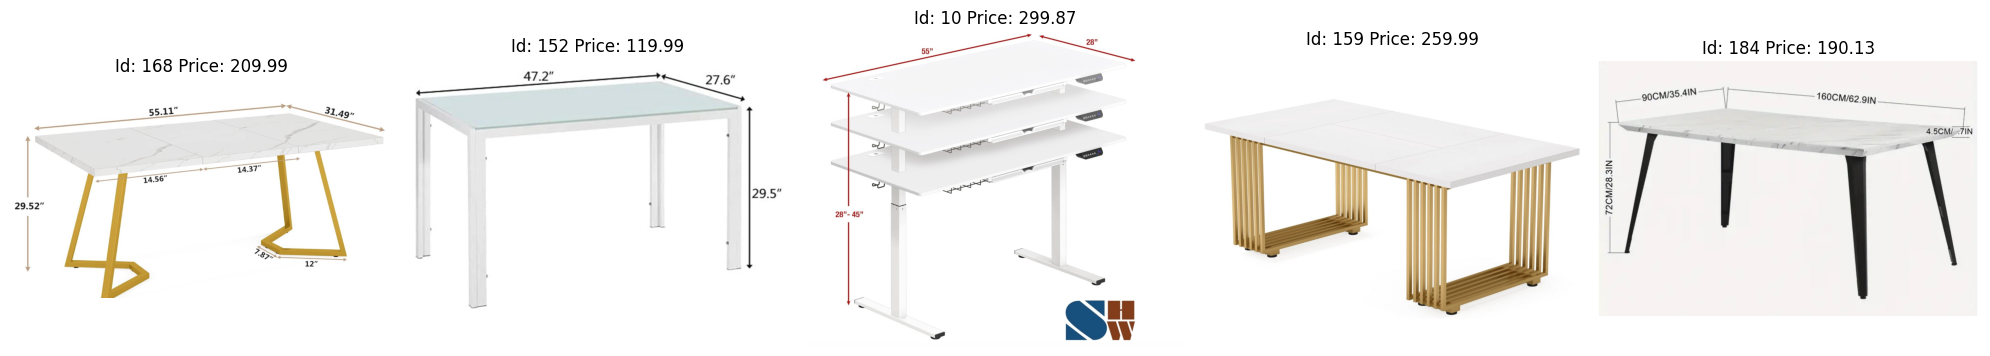

In [64]:
import matplotlib.pyplot as plt
import os

def display_product_info(sorted_database):
    # Limit the number of items to display to the number of subplots (5 in this case)
    num_items_to_display = min(len(sorted_database), 5)

    fig, axs = plt.subplots(1, num_items_to_display, figsize=(20, 4))

    # If there's only one item, axs will not be a list but a single Axes object
    if num_items_to_display == 1:
        axs = [axs]

    for i in range(num_items_to_display):
        image_id = sorted_database['img_dir'].iloc[i]
        img_path = f"/content/drive/MyDrive/ECE1786/ECE1786_project/data/{image_id}"
        if not os.path.exists(img_path):
            print(f"Product {image_id} image not exist")
            continue
        #pick one image from folder
        for filename in os.listdir(img_path):
            if filename.endswith(".jpg"):
                img_path = os.path.join(img_path, filename)
                break


        # Read and display the image
        image = plt.imread(img_path)
        axs[i].imshow(image)
        axs[i].axis('off')
        axs[i].set_title(f"Id: {image_id} Price: {sorted_database['price'].iloc[i]}")

    fig.tight_layout()
    plt.show()

# Call the function
display_product_info(sorted_database)


User: User query: I need a dining table for a compact dining area. It should seat four people, be white, have a length of 59 inch, a depth of 30 inch, a height of 29 inch, and cost under 300.
 Extract the search key from user query, like color, size, price. For the size I want the unit in inch. 
 Output Format: color:[COLOR]/ L: [LENGTH SIZE] - W: [WIDTH SIZE] - H: [HIGHT SIZE],inch / price: [PRICE] 
 Assistant: color: white / L: 59 - W: 30 - H: 29, inch / price: 300


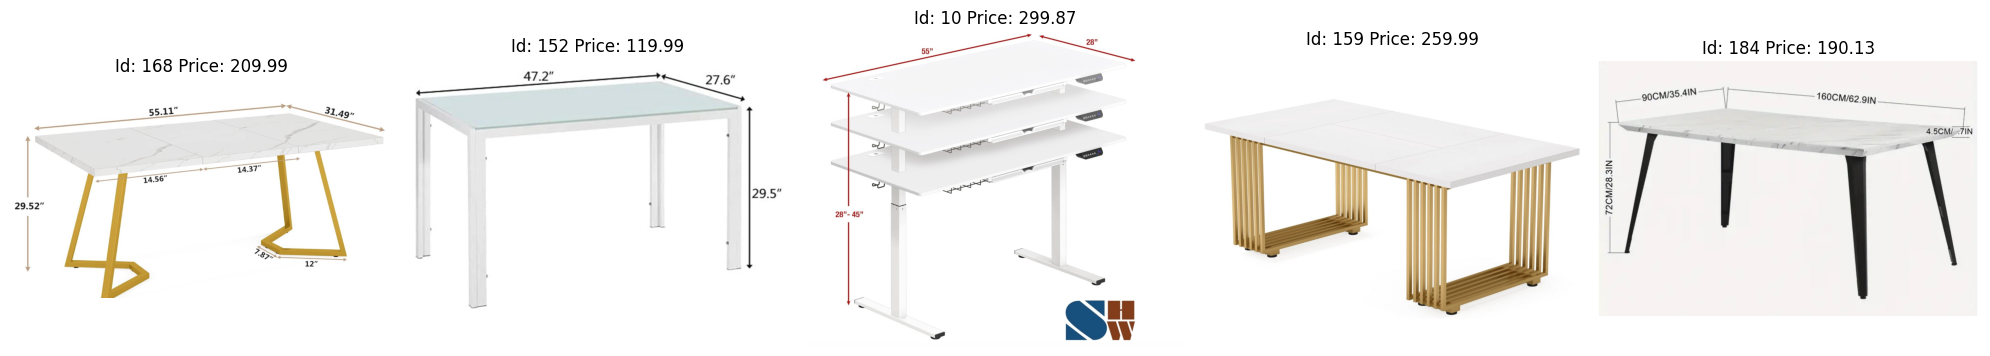

,Unnamed: 0,img_dir,price,color,length,width,height,area,difference
167,167,168,209.99,white,55.11,31.49,29.52,1735.4139,34.5861
151,151,152,119.99,white,57.20,27.60,29.50,1578.7200,191.2800
9,9,10,299.87,white,55.00,28.00,28.00,1540.0000,230.0000
158,158,159,259.99,white,70.86,31.10,30.70,2203.7460,433.7460
183,183,184,190.13,white,62.90,35.40,28.30,2226.6600,456.6600


In [65]:
def product_match_pipeline(query, model, tokenizer):
  response = user_query_feature_extract(query, model, tokenizer)
  output = userq_response_anlysis(response)
  product_database = pd.read_csv('/content/drive/MyDrive/ECE1786/ECE1786_project/product_database.csv')
  sorted_database = find_closest_match(product_database, output)
  display_product_info(sorted_database)
  return sorted_database

query = "I need a dining table for a compact dining area. It should seat four people, be white, have a length of 59 inch, a depth of 30 inch, a height of 29 inch, and cost under 300."
product_match_pipeline(query, model_8b, tokenizer)

# Draft

In [ ]:
# pure-text conversation (纯文本对话)
question = 'Hello, who are you?'
response, history = model.chat(tokenizer, None, question, generation_config, history=None, return_history=True)
print(f'User: {question}\nAssistant: {response}')

User: Hello, who are you?
Assistant: I am an AI assistant whose name is InternVL, developed jointly by Shanghai AI Lab and SenseTime.


In [ ]:
#131
# img_path = '/content/gdrive/MyDrive/ECE1786_project/data/131/61pRFf7llaL._AC_SL1500_.jpg'
# product_title = 'Baxton Studio Sherwin Mid-Century Modern Walnut Brown Finished Wood Dining Table'
# price = '468.7'

In [ ]:
# single-image single-round conversation (单图单轮对话)
img_path = '/content/gdrive/MyDrive/ECE1786_project/data/192/192.jpg'
product_title = 'Dining Table 31.5x31.5x29.92 inch High Gloss White'
price = '468.7'
prompt_sg = f"Product image1:<image>\nProduct title:{product_title} price is {price}\nExtract features based on the image and title.\nFeatures:"
pixel_values = load_image(img_path, max_num=12).to(torch.bfloat16).cuda()
question = prompt_sg
response = model.chat(tokenizer, pixel_values, question, generation_config)
print(f'User: {question}"{response}"')

User: Product image1:<image>
Product title:Baxton Studio Sherwin Mid-Century Modern Walnut Brown Finished Wood Dining Table price is 468.7
Extract features based on the image and title.
Features:"Color: walnut brown / L: 47.20 - W: 29.50 - H: 29.90, inch / Price: 468.70"


In [ ]:
# multi-image multi-round conversation, combined images (多图单轮对话，拼接图像)
pixel_values1 = load_image('./examples/image1.jpg', max_num=12).to(torch.bfloat16).cuda()
pixel_values2 = load_image('./examples/image2.jpg', max_num=12).to(torch.bfloat16).cuda()
pixel_values = torch.cat((pixel_values1, pixel_values2), dim=0)

question = '<image>\nDescribe the two images in detail.'
response, history = model.chat(tokenizer, pixel_values, question, generation_config,
                               history=None, return_history=True)
print(f'User: {question}\nAssistant: {response}')


In [ ]:
# multi-image multi-round conversation, separate images (多图多轮对话，独立图像)
pixel_values1 = load_image('./examples/image1.jpg', max_num=12).to(torch.bfloat16).cuda()
pixel_values2 = load_image('./examples/image2.jpg', max_num=12).to(torch.bfloat16).cuda()
pixel_values = torch.cat((pixel_values1, pixel_values2), dim=0)
num_patches_list = [pixel_values1.size(0), pixel_values2.size(0)]

question = 'Image-1: <image>\nImage-2: <image>\nDescribe the two images in detail.'
response, history = model.chat(tokenizer, pixel_values, question, generation_config,
                               num_patches_list=num_patches_list,
                               history=None, return_history=True)
print(f'User: {question}\nAssistant: {response}')

In [66]:
import re
import pandas as pd

# Input data as a string


# Regular expressions to extract color, size, and price
color_pattern = r'Color:\s*([a-zA-Z\s]+)'
size_pattern = r'L:\s*([\d.]+)[\s/-]*W:\s*([\d.]+)[\s/-]*H:\s*([\d.]+)'
price_pattern = r'Price:\s*\$?([\d,]+\.\d+)'

# Lists to store extracted data
colors = []
lengths = []
widths = []
heights = []
prices = []

# Extract each line and process it
for line in response_recording:
    if line.strip():
        # Extract color
        color_match = re.search(color_pattern, line)
        color = color_match.group(1).strip() if color_match else None

        # Extract size (L, W, H)
        size_match = re.search(size_pattern, line)
        if size_match:
          length, width, height = size_match.groups()
        else:
          length, width, height = None, None, None

        # Extract price
        price_match = re.search(price_pattern, line)
        price = float(price_match.group(1).replace(',', '')) if price_match else None

        # Append to lists
        colors.append(color)
        lengths.append(length)
        widths.append(width)
        heights.append(height)
        prices.append(price)

# Create a DataFrame for better readability
print(colors)
print(lengths)
print(widths)
print(heights)
print(prices)

['black', 'cherry', 'wood', 'white', 'espresso', None, 'white', 'ZINUS', 'wood', 'grey']
['40', '55', '55', None, None, '84', '47.2', '37.8', None, '47.2']
['19', '23.8', '23.8', None, None, '36', '27.6', '47.2', None, '27.2']
['28', '28', '28', None, None, '29', '29.5', '47.2', None, '25.8']
[88.97, 169.87, 169.87, 99.87, 99.87, None, 119.99, 459.99, 119.99, 119.99]


In [ ]:
# Directory to save the model and tokenizer
save_directory = '/content/drive/MyDrive/ECE1786_project/internvl-8B'

# Save the model
model.save_pretrained(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

('/content/gdrive/MyDrive/ECE1786_project/internvl-8B/tokenizer_config.json',
 '/content/gdrive/MyDrive/ECE1786_project/internvl-8B/special_tokens_map.json',
 '/content/gdrive/MyDrive/ECE1786_project/internvl-8B/./tokenizer.model',
 '/content/gdrive/MyDrive/ECE1786_project/internvl-8B/added_tokens.json')

In [83]:
import re
import pandas as pd

# Input data
data = """
Color: black / L: 40 - W: 28 - H: 19-inch / Price: 88.97
Color: red / L: 55 - W: 23.8 - H: 28, inch / Price: 169.87
Color: beige / L: 55 - W: 23.8 - H: 28, inch / Price: $69.87
Color: white / L: 43 inch / W: 7.5 inch / H: 16 inch, Price: 99.87
Color: espresso / L: 43, - W: 20, - H: 30,-inch / Price: 99.87
Color: black / L: 84 cm - W: 84 cm - H: 90 cm / Price: 119.99
Color: lime green / L: 47.2 - W: 27.6 - H: 29.5, inch / Price: 119.99
Color: espresso / L: 47.2 - W: 29.5 - H: 37.8 / Price: 0.00
Color: wood / L: 47.2 - W: 27.2 - H: 29.5, inch / Price: $119.99
Color: Lime / L: 47.2 - W: 27.2 - H: 25.8, inch / Price: 119.99
"""

# Regular expressions to extract color, size, and price
color_pattern = r'Color:\s*([\w\s]+)'
size_pattern = r'L:\s*([\d.]+)[\s,-]*W:\s*([\d.]+)[\s,-]*H:\s*([\d.]+)'
price_pattern = r'Price:\s*\$?([\d,]+\.\d+)'

# Lists to store extracted data
colors, lengths, widths, heights, prices = [], [], [], [], []

# Extract each line and process it
lines = data.split('\n')
for line in lines:
    if line.strip():
        # Extract color
        color_match = re.search(color_pattern, line, re.IGNORECASE)
        color = color_match.group(1).strip() if color_match else None

        # Extract size (L, W, H)
        size_match = re.search(size_pattern, line)
        if size_match:
            length, width, height = size_match.groups()
        else:
            length, width, height = None, None, None

        # Extract price with optional "$" sign
        price_match = re.search(price_pattern, line)
        price = float(price_match.group(1).replace(',', '')) if price_match else None

        # Append to lists
        colors.append(color)
        lengths.append(length)
        widths.append(width)
        heights.append(height)
        prices.append(price)

# Create a DataFrame for better readability
df = pd.DataFrame({
    'Color': colors,
    'Length': lengths,
    'Width': widths,
    'Height': heights,
    'Price': prices
})

df


,Color,Length,Width,Height,Price
0,black,40,28,19,88.97
1,red,55,23.8,28,169.87
2,beige,55,23.8,28,69.87
3,white,None,None,None,99.87
4,espresso,43,20,30,99.87
5,black,None,None,None,119.99
6,lime green,47.2,27.6,29.5,119.99
7,espresso,47.2,29.5,37.8,0.00
8,wood,47.2,27.2,29.5,119.99
9,Lime,47.2,27.2,25.8,119.99
